<a href="https://colab.research.google.com/github/vivomouallem12-oss/Cloud-Project/blob/main/Practice10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.1 findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = "python3"

findspark.init()

In [3]:
!java -version

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)


In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Measurements Analysis") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

spark

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = spark.read.json("/content/drive/MyDrive/json-20251229-2107.json")

In [7]:
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import StructType, StructField, DoubleType

schema = StructType([
    StructField("temperature", DoubleType(), True),
    StructField("humidity", DoubleType(), True),
    StructField("soil", DoubleType(), True),
    StructField("tempThreshold", DoubleType(), True),
    StructField("humThreshold", DoubleType(), True)
])

df_parsed = df.withColumn("measurements", from_json(col("value"), schema))

df_clean = df_parsed.select(
    "created_at",
    col("measurements.temperature").alias("temperature"),
    col("measurements.humidity").alias("humidity"),
    col("measurements.soil").alias("soil"),
    col("measurements.tempThreshold").alias("tempThreshold"),
    col("measurements.humThreshold").alias("humThreshold")
)

df_clean.show(10)
df_clean.printSchema()

+--------------------+-----------+--------+-----+-------------+------------+
|          created_at|temperature|humidity| soil|tempThreshold|humThreshold|
+--------------------+-----------+--------+-----+-------------+------------+
|2025-12-06T08:10:...|       21.3|    36.0|100.0|         30.0|        60.0|
|2025-12-06T08:20:...|       22.6|    31.0|100.0|         30.0|        60.0|
|2025-12-06T08:58:...|       23.0|    35.0| 58.0|         NULL|        NULL|
|2025-12-06T09:00:...|       23.0|    34.0| 42.0|         NULL|        NULL|
|2025-12-06T09:01:...|       23.3|    34.0| 38.0|         NULL|        NULL|
|2025-12-06T09:02:...|       23.2|    34.0|100.0|         NULL|        NULL|
|2025-12-06T09:02:...|       23.3|    33.0| 91.0|         NULL|        NULL|
|2025-12-06T09:12:...|       23.3|    34.0| 60.0|         NULL|        NULL|
|2025-12-06T09:22:...|       23.4|    33.0| 58.0|         NULL|        NULL|
|2025-12-06T09:32:...|       23.4|    33.0| 55.0|         NULL|        NULL|

In [8]:
measurement_columns = ["temperature", "humidity", "soil", "tempThreshold", "humThreshold"]

results = {}

for param in measurement_columns:

    # MAP step: convert every value to (parameter_name, value)
    rdd = df_clean.select(param).dropna().rdd \
        .map(lambda row: (param, float(row[0])))

    if rdd.isEmpty():
        continue

    # REDUCE step: calculate max
    max_value = rdd.reduceByKey(lambda a, b: max(a, b)).collect()[0][1]

    # REDUCE step: calculate min
    min_value = rdd.reduceByKey(lambda a, b: min(a, b)).collect()[0][1]

    results[param] = {
        "min": min_value,
        "max": max_value
    }

results

{'temperature': {'min': 17.4, 'max': 26.6},
 'humidity': {'min': 27.0, 'max': 57.0},
 'soil': {'min': 8.0, 'max': 100.0},
 'tempThreshold': {'min': 30.0, 'max': 30.0},
 'humThreshold': {'min': 60.0, 'max': 60.0}}

In [9]:
pandas_df = df.toPandas()

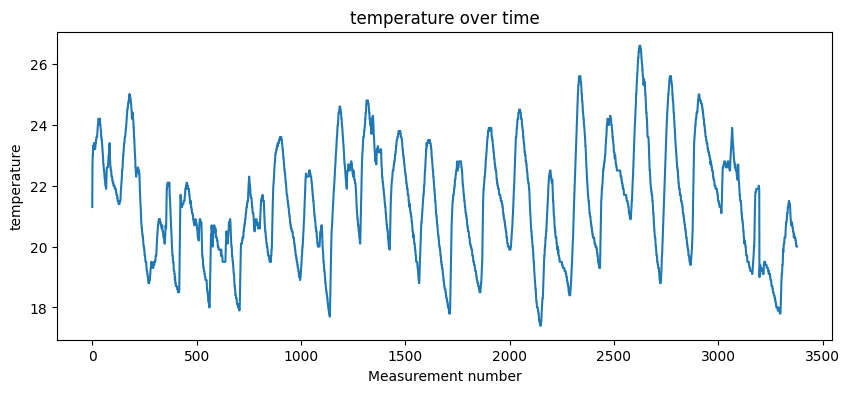

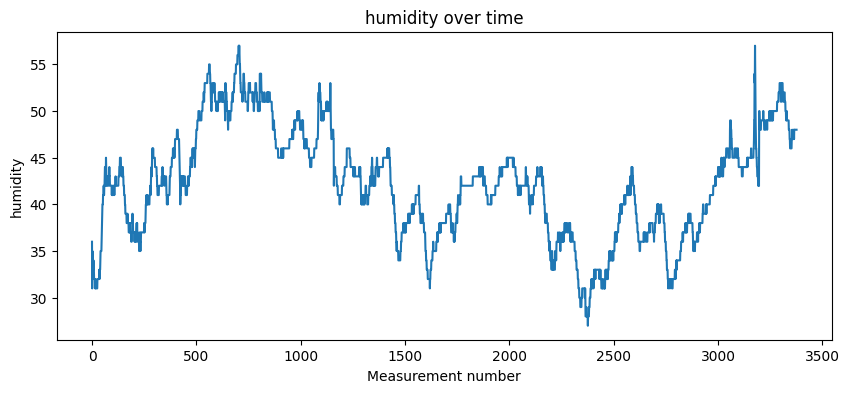

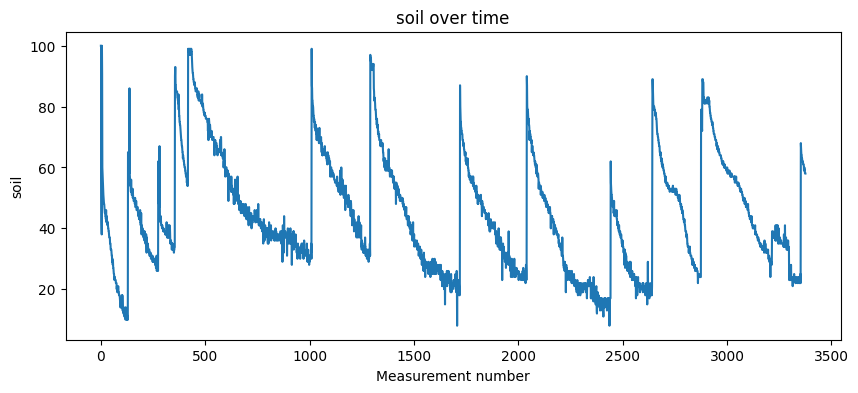

In [10]:
import matplotlib.pyplot as plt

pdf = df_clean.toPandas()

for param in ["temperature", "humidity", "soil"]:
    plt.figure(figsize=(10, 4))
    plt.plot(pdf[param])
    plt.title(f"{param} over time")
    plt.xlabel("Measurement number")
    plt.ylabel(param)
    plt.show()